<a href="https://colab.research.google.com/github/dr-bankert-augustana/PHYS_200/blob/main/Lessons/Module_3/Lesson_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a name="Notebook-Start"></a>

---

<font size = 7> <b> Lesson 3.1 (Simulation Models) </b> </font>

---

<font size = 5> <b> Notebook Index </b> </font>

1.  [Learning Outcomes](#Learning-Outcomes)

2.  [Introduction](#Introduction)

3.  [Implementing the State](#State)

4.  [Changing the State](#Change)

5.  [Stepping Forward In Time](#Time)
$
\newcommand{\lsum}{\displaystyle \sum\limits_{i=1}^{N}}
\newcommand{\parens}[1]{\left(#1\right)}
\newcommand{\dsfrac}[2]{\displaystyle\frac{#1}{#2}}
\newcommand{\dpfrac}[2]{\displaystyle\parens{\frac{#1}{#2}}}
\newcommand{\parderiv}[2]{\dsfrac{\partial #1}{\partial #2}}
\newcommand{\spc}{\hspace{0.1 pc}}
\newcommand{\ra}{\Rightarrow}
\newcommand{\of}[1]{{\scriptsize (#1)}}
\newcommand{\rule}{\Huge \hspace{-0.2 pc} \displaystyle\frac{\hspace{20 pc}}{\hspace{20 pc}}}
\newcommand{\mps}{\spc \frac{\textrm{m}}{\textrm{s}}}
\newcommand{\mpss}{\spc \frac{\textrm{m}}{\textrm{s}^2}}
$

<a name="Learning-Outcomes"></a>

---

<font size = 6> <b> 1. Learning Outcomes </b> </font>

---

<font size = 5> <b> Learning Outcomes: </b> </font>

By the end of this lesson, students will be able to:

  <br>

  1. <b>Explain</b>

[Return to Top](#Notebook-Start)

<a name="Introduction"></a>

---

<font size = 6> <b> 2. Introduction </b> </font>

---

<font size = 5> <b> 2.1 Introducing the Bike-share Problem </b> </font>

<p align = 'justify'>
One purpose of modeling is to optimize an engineered system. In the next few lessons, we are going to create a simulation to do just that.
</p>

<br>

<p align = 'justify'>
We are interested in instituting a bike share system for students traveling between Augie and downtown Moline. By observation, we know that more students use the bikes to get from Augie to Moline than the reverse, so bikes tend to build up at Moline. We only want to move bikes once every day from Moline to Augie. We know we have 12 bikes in total.
</p>

<br>

<p align = 'justify'>
 <b>If we want as few disappointed customers as possible, how many bikes should we put in each place at the start of the day?</b>
</p>

<center>$\rule$</center>

<font size = 5> <b> 2.2 Investigating the System </b> </font>

<p align = 'justify'>
To build our model, we need to know something about our system. <b>We need to start with an investigation.</b>
</p>

<br>

We know that we have 12 bikes, and that buying more would be a significant investment, so we'd like to avoid that. To find out how the bikes move between places, let's say we put a camera on the Augie bike rack, and bikes are taken out at the following times one Thursday:

<br>

<table>
  <thead>
    <tr>
      <th colspan="8"><font size = 4>Between 8 AM and Noon</font></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><br><font size = 3>8:14</font></td>
      <td><br><font size = 3>8:17</font></td>
      <td><br><font size = 3>8:58</font></td>
      <td><br><font size = 3>10:02</font></td>
      <td><br><font size = 3>10:02</font></td>
      <td><br><font size = 3>10:22</font></td>
      <td><br><font size = 3>10:43</font></td>
      <td><br><font size = 3>11:41</font></td>
    </tr>
  </tbody>
</table>

<br>

<table>
  <thead>
    <tr>
      <th colspan="8"><font size = 4>Between Noon and 4 PM</font></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><br><font size = 3>12:37</font></td>
      <td><br><font size = 3>12:55</font></td>
      <td><br><font size = 3>2:10</font></td>
      <td><br><font size = 3>2:10</font></td>
      <td><br><font size = 3>3:06</font></td>
      <td><br><font size = 3>3:22</font></td>
      <td><br><font size = 3>3:29</font></td>
      <td><br><font size = 3>3:55</font></td>
    </tr>
  </tbody>
</table>

<br>

<b>What does this tell us about our system?</b>

<br>

First, we might consider the overall averages: 16 bikes are taken over the course of 8 hours, or 2 per hour.  

<br>

Next, we might consider patterns: there seems to be a rush in the late afternoon, and maybe one in the morning, but we might need more data to confirm that.  We also notice that twice two people (friends?) take out bikes at the same time.

<br>

We also know from experience that customers complain that the Augie rack is empty more often than that the Moline rack is empty: so it seems like the rate of pickup might be slower in Moline.

<br>

Ideally, we'd want to get more data to decide if these patterns were important: maybe Saturdays are a lot different than Thursdays, too!  But this at least gives us a starting point.

<center>$\rule$</center>

<font size = 5> <b> 2.3 Abstracting the System </b> </font>

Abstraction is about simplification, particularly when we are preparing the initial implementation. So at least for now, we'll ignore time-based patterns (time of day, day of the week). So we'll determine a constant likelihood of someone picking up a bike within a given time period.

<br>

2 people on average pick up a bike per hour. But if we made that the "rule" of our model, the model would not work very well.

<br>

So let's subdivide the hour. We'll say that in any given 15 minutes, there is a 50% chance that someone will pick up a bike at the Augie bikerack. Because pickups are less frequent in Moline, we'll make the rate 40% at the Moline rack. In the simulation, 15 minutes will be the length of each time step: <b>the length of time between each update of the system.</b>

<br>

These abstraction decisions gives us our set of rules that will guide our implementation. This is our inital model!

<center>$\rule$</center>

<font size = 5> <b> 2.4 Model Variable Vocabulary</b> </font>

Once we've abstracted a system, the initial model is effectively complete: how do we describe that model, though, before we have created a simulation?  The following four terms go a long way to describing the shape and purpose of a model.

<br>

* <b>Independent variable(s)</b>

  > An independent variable is a variable that the model-maker can change to explore the behavior of the system.  In this case, the key independent variable is the initial numbers of bikes at Moline and Augie.

<br>

* <b>State variable(s)</b>

  > Most models attempt to describe some system that changes over time.  How does the population grow? When will the company start to make a profit? How does the rocket re-enter the atmosphere?  State variables describe the state of a system at a given time step (the current population, the company's current financial situation, the rocket in space, etc...).   Notice that the *initial state* is an independent variable (see previous note), but the state during the simulation is not directly controlled by the model-maker.

  The state variables here are the number of bikes at Moline and Augie at any time other than $t=0$.

<br>

* <b>Parameter(s)</b>

  > Parameters are values that describe the system of interest, but which do not change.   In this case, the total number of bikes (12) is a parameter, as are the rates at Moline and Augie (40% and 50%).  Notice that in a different model, these might be independent variables (i.e. would it be worth it to buy more bikes?).  Another parameter would be the length of the simulation: let's say business starts up at 7 am and slows down after 10 pm.  So every simulation will last 15 hours.

<br>

* <b>Metric(s)</b>

  > Most models are created to evaluate the behavior of a system in given conditions.   The *metric* is a single value that describes how well the system is functioning.  For instance, assuming we don't want unhappy customers, a metric here might be the chance that the system makes it through the day without having an empty bike rack at either Moline or Augie.   A metric boils the complex results of a simulation to a manageable number (or small set of numbers).

[Return to Top](#Notebook-Start)

<a name="State"></a>

---

<font size = 6> <b> 3. Implementing the State </b> </font>

---

<font size = 5> <b> 3.1 Summarizing Our Abstraction </b> </font>

We have now transformed a system into a model by defining the 4 types of variables. Let's review our decisions:

<br>

<b>Parameters:</b>

* Total number of bikes: 12
* Length of simulation: 15 hours
* Time steps: 15 minutes (for a total of 60 time steps)
* Chance of bike being picked up in a time step: 50% (from Augie), 40% (from Moline)

<br>

<b>Independent variables:</b>

* Number of bikes starting at Augie: 0-12 (the initial state)

<br>

<b>State variables:</b>

* Number of bikes at Augie and Moline at a given moment

<br>

<b>Metrics:</b>

* Chance of having no empty racks? Number of unhappy customers?

<br>

Now we need to begin the implementation process. We define the parameters and independent variables before the simulation begins, and metrics won't become important until we get a running simulation. So our main aim will be to establish:

* a tool to keep track of the state variables as they change.

* a rule for how they will change (*a change function*).

<center>$\rule$</center>

<font size = 5> <b> 3.2 Keeping Track of the State Variables </b> </font>

In order to store the state, we'll use a Pandas `DataFrame`.

<br>

 ><b>Recall:</b> A Pandas `Series` is an object that holds a set of variable values in a table-like form, like a two-column spreadsheet.

<br>

We'll start by importing the Pandas library and creating a `Series` called `bikeshare`.  This will be our *state object*: it will hold up-to-date information about the state of our system.

In [1]:
##=============================================================================================##
## Import the Pandas Library:                                                                  ##
##=============================================================================================##

import pandas as pd

##=============================================================================================##
## Create the Simulation Parameters:                                                           ##
##=============================================================================================##

# Total Number of Bikes:

n_bikes = 12

# Total Number of Steps:

n_steps = 60

# Chance of Bike Picked up at Augie and Taken to Moline:

p_to_moline = 0.5

# Chance of Bike Picked up at Moline and Taken to Augie:

p_to_augie = 0.4

##=============================================================================================##
## Create the State Object:                                                                    ##
##=============================================================================================##

# Create a Dictionary Storing the Initial State of the Simulation:

initial_state = {"augie" : 10, "moline" : 2}

# Convert the Dictionary Into a Pandas Series:

system_state = pd.Series(initial_state, name = 'Number of Bikes')

# Rename the Series Index:

system_state.index.name = 'Location'

# Display the Initial State:

display(system_state)

,Number of Bikes
Location,
augie,10
moline,2


[Return to Top](#Notebook-Start)

<a name="Change"></a>

---

<font size = 6> <b> 4. Changing the State </b> </font>

---

<font size = 5> <b> 4.1 Introducing the Change Function </b> </font>

Ok, we now have a place to store the state variables.  But in any useful model, the state is going to change.

<br>

In a model, the process of change must be defined by a rule, or a set of rules, about how this change occurs.  We will call these rules a <b>change function</b>.  Much of these next few lessons will be spent exploring different types of change functions.  These rules might stay the same the whole time, or they might change, gradually or suddenly.  The rules might create random *stochastic* changes, or established *deterministic* changes.

<br>

The change occurs through <b>time steps</b>.  Each time step represents a certain amount of time, and each step represents a change in the state of the system.  We have defined our time step as being 15 minutes.

<br>

At its most basic, we enact the change function manually: that is, we can update the state by assigning new values to the variables. For example, if a student moves a bike from Augie to Moline, we can figure out the new values and assign them:

In [2]:
##=============================================================================================##
## First Simple Change Function (Not an actual function):                                      ##
##=============================================================================================##

# Manually Update the Number of Bikes at Augie:

system_state.augie = 9

# Manually Update the Number of Bikes at Moline:

system_state.moline = 3

# Display the New System State:

display(system_state)

,Number of Bikes
Location,
augie,9
moline,3


That's not particularly efficient, though.  One step better, we can avoid doing the math ourselves by using *update operators*, `-=` and `+=`, to subtract 1 from `augie` and add 1 to `moline`:

In [3]:
##=============================================================================================##
## Second Simple Change Function (Not an actual function):                                     ##
##=============================================================================================##

# Remove a Bike from the Number of Bikes at Augie:

system_state.augie -= 1

# Add a Bike to the Number of Bikes at Moline:

system_state.moline += 1

# Display the New System State:

display(system_state)

,Number of Bikes
Location,
augie,8
moline,4


<center>$\rule$</center>

<font size = 5> <b> 4.2 A Change Function (That Actually is a Function) </b> </font>

The advantage of using a computer to create a model (i.e. of creating *simulations*) is that we don't have to manually enter the change for each time step.  We want to define the rule (that is, the change function) and let the computer do the grunt work.

<br>

When we want to do something over and over in code, we use a *function*.  A  function allows us to write a few lines of code, test them to confirm they do what we intend, and then *call* that function everytime we want to perform those actions.

<br>

Next, we'll set up a function that will change our state variable with each time step.

In [4]:
##=============================================================================================##
## A Simple Change Function (That is an actual function):                                      ##
##=============================================================================================##

# Define the function that 'transports' a bike from Augie to Moline:

def bike_to_moline(state):

    # Remove a bike from Augie:

    state.augie -= 1

    # Add a bike to Moline:

    state.moline += 1

    # Return the altered system_state:

    return state

# Display the original system state:

print("System Before Calling The Change Function:\n")
display(system_state)
print('\n\n')

# Call the change function to alter the system's state:

system_state = bike_to_moline(system_state)

# Display the altered system state:

print("System After Calling The Change Function:\n")
display(system_state)

System Before Calling The Change Function:



,Number of Bikes
Location,
augie,8
moline,4





System After Calling The Change Function:



,Number of Bikes
Location,
augie,7
moline,5


Likewise, we can create a change function that transports bikes from Moline to Augie by following the same prescription as above.

In [5]:
##=============================================================================================##
## A Simple Change Function (Moline to Augie):                                                 ##
##=============================================================================================##

# Define the function that 'transports' a bike from Moline to Augie:

def bike_to_augie(state):

    # Remove a bike from Moline:

    state.moline -= 1

    # Add a bike to Augie:

    state.augie += 1

    # Return the altered system_state:

    return state

# Display the original system state:

print("System Before Calling The Change Function:\n")
display(system_state)
print('\n\n')

# Call the change function to alter the system's state:

system_state = bike_to_augie(system_state)

# Display the altered system state:

print("System After Calling The Change Function:\n")
display(system_state)

System Before Calling The Change Function:



,Number of Bikes
Location,
augie,7
moline,5





System After Calling The Change Function:



,Number of Bikes
Location,
augie,8
moline,4


<center>$\rule$</center>

<font size = 5> <b> 4.3 Adding an Element of Chance </b> </font>

We now have a way to keep track of the state of the system (*state variables*), and a rule for how things will change when a bike is moved (*change function*).  But how do we know if a bike is actually moved in a given time step?

<br>

We can do this by building a logical if-then evaluator of a randomly generated value. <b>If</b> the value falls within the bounds of probability that a bike is moved from one location to another, within a single time step, <b>then</b> we initiate the move.

In [6]:
##=============================================================================================##
## Import the 'random' Functions from the Numpy Library:                                       ##
##=============================================================================================##

import numpy.random as npr

##=============================================================================================##
## A More Robust Change Function:                                                              ##
##=============================================================================================##

# Define the Change Function:

def change_function(state, debug = False):

  # Define the 'to_moline' random number:

  random_to_moline = npr.random()

  # Define the 'to_augie' random number:

  random_to_augie = npr.random()

  # Check to see if 'random_to_moline' is less than the threshold for calling 'bike_to_moline':

  if (random_to_moline < p_to_moline): state = bike_to_moline(state)

  # Check to see if 'random_to_moline' is less than the threshold for calling 'bike_to_augie':

  if (random_to_augie < p_to_augie): state = bike_to_augie(state)

  # Check the internal values if debug is True:

  if (debug == True):

    print("Threshold to Moline: " + str(p_to_moline))
    print("Random to Moline: " + str(random_to_moline))

    if (random_to_moline < p_to_moline): print("Bike Moved to Moline")
    else: print("Bike Not Moved to Moline")

    print()
    print("Threshold to Augie: " + str(p_to_augie))
    print("Random to Augie: " + str(random_to_augie))

    if (random_to_augie < p_to_augie): print("Bike Moved to Augie")
    else: print("Bike Not Moved to Augie")

    print()

  # Return the updated system state:

  return state

Now let's test out our new change function. You'll notice that we included some debugging code in our function, but set it to not display by default. In the code below, try changing `debug = False` to `debug = True` after you've run it the way it's written.

In [7]:
# Display the original system state:

print("System Before Calling The Change Function:\n")
display(system_state)
print('\n\n')

# Call the change function to alter the system's state:

system_state = change_function(system_state, debug = False)

# Display the altered system state:

print("System After Calling The Change Function:\n")
display(system_state)

System Before Calling The Change Function:



,Number of Bikes
Location,
augie,8
moline,4





System After Calling The Change Function:



,Number of Bikes
Location,
augie,9
moline,3


Depending on the results, this function might move a bike to augie, or to moline, or neither, or both.  Run change_func multiple times and note how the state of the system changes.

<br>

`change_function` is our first fully-formed change function!  We can run this function $n$ number of times, and it will simulate the changes in the state of the system over a period of $n*15$ minutes.

<center>$\rule$</center>

<font size = 5> <b> 4.4 Using Parameters to Add Flexibilty to a Change Function </b> </font>

The previous version of `change_function` is fine if the arrival probabilities
never change, but in reality they may vary over time, especially as our simulation gets more complex.  So instead of using the previously declared constant values 0.5 and 0.4 in `change_function`, we can replace them with <b>arguments</b>, which is just coding vocabulary for "inputs".

<br>

As we've seen, in a function, inputs/ arguments are variables whose values are set only when a function is called. As with a mathematical function, a coding function can have multiple inputs.

<br>

Next, we build a version of `change_function` that takes the probabilities as inputs.

In [8]:
##=============================================================================================##
## A More Robust Change Function:                                                              ##
##=============================================================================================##

# Define the Change Function:

def change_function_2(state, prob_to_moline, prob_to_augie, debug = False):

  # Define the 'to_moline' random number:

  random_to_moline = npr.random()

  # Define the 'to_augie' random number:

  random_to_augie = npr.random()

  # Check to see if 'random_to_moline' is less than the threshold for calling 'bike_to_moline':

  if (random_to_moline < prob_to_moline): state = bike_to_moline(state)

  # Check to see if 'random_to_moline' is less than the threshold for calling 'bike_to_augie':

  if (random_to_augie < prob_to_augie): state = bike_to_augie(state)

  # Check the internal values if debug is True:

  if (debug == True):

    print("Threshold to Moline: " + str(prob_to_moline))
    print("Random to Moline: " + str(random_to_moline))

    if (random_to_moline < prob_to_moline): print("Bike Moved to Moline")
    else: print("Bike Not Moved to Moline")

    print()
    print("Threshold to Augie: " + str(prob_to_augie))
    print("Random to Augie: " + str(random_to_augie))

    if (random_to_augie < prob_to_augie): print("Bike Moved to Augie")
    else: print("Bike Not Moved to Augie")

    print()

  # Return the updated system state:

  return state

The values of `prob_to_moline` and `prob_to_augie` are not set inside this function; instead, they are provided when the function is called.

In [9]:
# Display the original system state:

print("System Before Calling The Change Function:\n")
display(system_state)
print('\n\n')

# Call the change function to alter the system's state:

system_state = change_function_2(system_state, 0.5, 0.4, debug = False)

# Display the altered system state:

print("System After Calling The Change Function:\n")
display(system_state)

System Before Calling The Change Function:



,Number of Bikes
Location,
augie,9
moline,3





System After Calling The Change Function:



,Number of Bikes
Location,
augie,9
moline,3


The arguments, `0.5` and `0.4` in this example, get assigned to the variables, `prob_to_moline` and `prob_to_augie`, in order. So inside the function, `prob_to_moline = 0.5` and `prob_to_augie = 0.4`.  The advantage of using arguments is that you can call the same function many times, providing different values each time.

<br>

Adding arguments to a function is called *generalization*, because it makes the function more general; without arguments, the function always does the same thing; with them, it can do a range of things.

[Return to Top](#Notebook-Start)

<a name="Time"></a>

---

<font size = 6> <b> 5. Stepping Forward In Time </b> </font>

---

<font size = 5> <b> 5.1 Moving the Simulation through Time </b> </font>

We have a way to keep track of the state of the system (*state variables*), and a rule for how things will change (*change function*). Now we need to see what happens when time moves forward!

<br>

We'll use a loop to move through a significant number of time steps (running the change function in each loop).  But when we run a simulation, we often want to save the results for later analysis. We can save those results in a `Series`.  

<br>

In this Series, the labels (the `index`) will be integers representing the time steps.  The values in the series will the number of bikes at Augie.  When we create the Series, which we'll call "results", it will be empty, because we don't know the values yet.

In [21]:
state_history = pd.DataFrame()
state_history.name='Bikes at Augie'
state_history.index.name = 'Time Step'

display(state_history)

""
Time Step


* The first line creates a `Series` with no values: the "[ ]" signifies there are no current values, but values might be added later. `dtype` tells it to expect any kind of object in the series.  

* The next two lines give a title to the index column and to the values column.

Now we can add the initial state (number of bikes at Augie) to our empty `Series` like this:

In [22]:
state_initial = pd.Series({"augie" : 10, "moline" : 2}, name = "Number of Bikes")
state_history[0] = state_initial

state_history = state_history.T

display(state_history)

Time Step,augie,moline
0,10,2


<center>$\rule$</center>

<font size = 5> <b> 5.2 Running the Simulation </b> </font>

Now we can begin our simulation!  We'll use a for-loop to run through the time steps, and save the changes in `results` for each step

Time Step,augie,moline
0,10,2
1,10,2
2,10,2
3,10,2
4,9,3
...,...,...
56,-4,16
57,-5,17
58,-5,17
59,-6,18


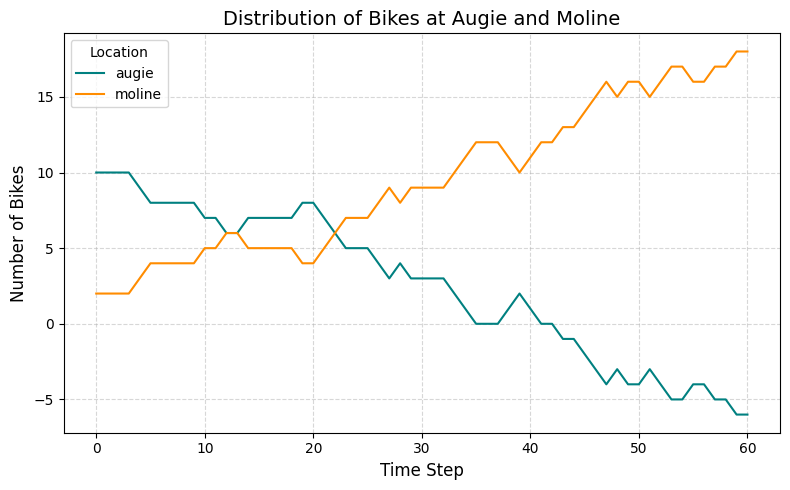

In [48]:
import matplotlib.pyplot as plt

# Set the number of steps:

n_steps = 60

# Create the state_history DataFrame:

state_history = pd.DataFrame()
state_history.name='Bikes at Augie'
state_history.index.name = 'Time Step'

# Reset the values of bikeshare

system_state = pd.Series({"augie" : 10, "moline" : 2})

# Set the initial value of the results

state_history[0] = system_state

state_history = state_history.T

# Run the simulation for 5 time steps:

for i in range(n_steps):

  system_state = change_function_2(system_state, 0.5, 0.4)

  state_history.loc[i + 1] = system_state.T

# Output the results

display(state_history)

# Create a graph of the state_history:

# Create the histogram plot

ax = state_history.plot(
    kind='line',
    y = ['augie', 'moline'],
    color=['teal', 'darkorange'],  # Custom colors
    figsize=(8, 5)
)

# Use Matplotlib to customize the plot:

# Add titles and labels:

ax.set_title("Distribution of Bikes at Augie and Moline", fontsize = 14)
ax.set_xlabel("Time Step", fontsize = 12)
ax.set_ylabel("Number of Bikes", fontsize = 12)

# Add grid and legend:

plt.grid(True, linestyle = '--', alpha=0.5)
plt.legend(title = "Location")

plt.tight_layout()
plt.show()